In [1]:
import pandas as pd
import numpy as np

# Text preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
# Load dataset
df = pd.read_csv('spam.csv', encoding='latin-1')

# Keep only required columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

# Display dataset
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [3]:
print(df.info())

print("\nDataset Shape:", df.shape)

print("\nClass Distribution:")
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Dataset Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
ps = PorterStemmer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Tokenization
    words = text.split()

    # Remove stopwords and stemming
    words = [ps.stem(word) for word in words
             if word not in stopwords.words('english')]

    return " ".join(words)

# Apply preprocessing
df['processed_message'] = df['message'].apply(preprocess_text)

print(df.head())

  label                                            message  \
0   ham  Go until jurong point, crazy.. Available only ...   
1   ham                      Ok lar... Joking wif u oni...   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3   ham  U dun say so early hor... U c already then say...   
4   ham  Nah I don't think he goes to usf, he lives aro...   

                                   processed_message  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri wkli comp win fa cup final tkt st m...  
3                u dun say earli hor u c alreadi say  
4               nah think goe usf live around though  


In [5]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['processed_message']).toarray()

y = df['label'].map({'ham': 0, 'spam': 1})

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (4457, 5000)
Testing Data Shape: (1115, 5000)


In [7]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [8]:
print("Naive Bayes Results")

print("Accuracy:", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall:", recall_score(y_test, nb_pred))
print("F1 Score:", f1_score(y_test, nb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))

Naive Bayes Results
Accuracy: 0.968609865470852
Precision: 1.0
Recall: 0.7666666666666667
F1 Score: 0.8679245283018868

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [9]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [10]:
print("Logistic Regression Results")

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Results
Accuracy: 0.95695067264574
Precision: 0.9636363636363636
Recall: 0.7066666666666667
F1 Score: 0.8153846153846154

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       0.96      0.71      0.82       150

    accuracy                           0.96      1115
   macro avg       0.96      0.85      0.90      1115
weighted avg       0.96      0.96      0.95      1115



In [11]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

In [12]:
print("SVM Results")

print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall:", recall_score(y_test, svm_pred))
print("F1 Score:", f1_score(y_test, svm_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred))

SVM Results
Accuracy: 0.9811659192825112
Precision: 0.9777777777777777
Recall: 0.88
F1 Score: 0.9263157894736842

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.98      0.88      0.93       150

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



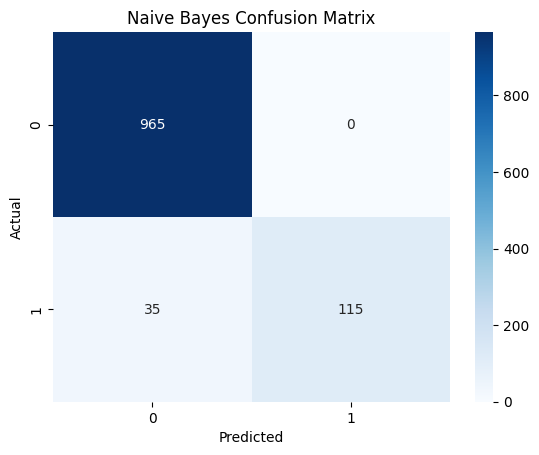

In [13]:
cm = confusion_matrix(y_test, nb_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

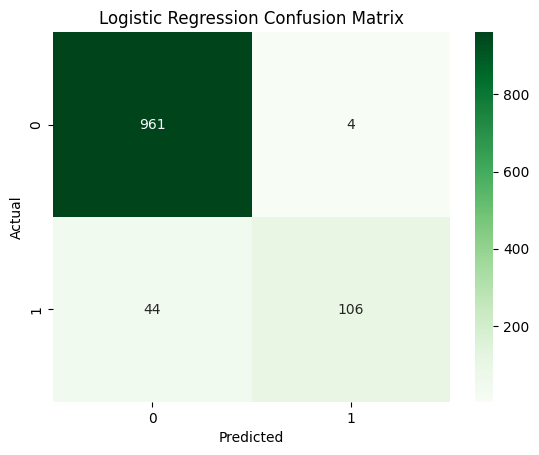

In [14]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

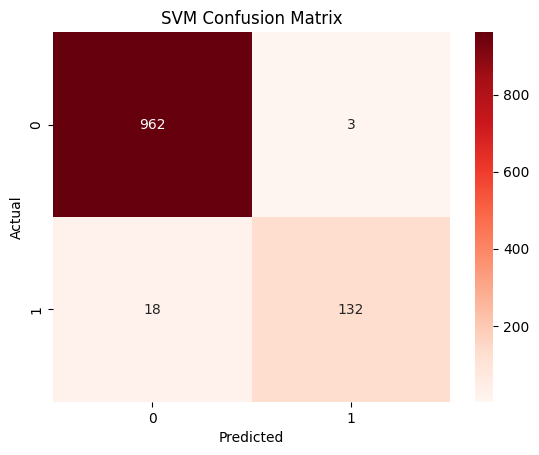

In [15]:
cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ],
    'F1 Score': [
        f1_score(y_test, nb_pred),
        f1_score(y_test, lr_pred),
        f1_score(y_test, svm_pred)
    ]
})

print(results)

                 Model  Accuracy  F1 Score
0          Naive Bayes  0.968610  0.867925
1  Logistic Regression  0.956951  0.815385
2                  SVM  0.981166  0.926316


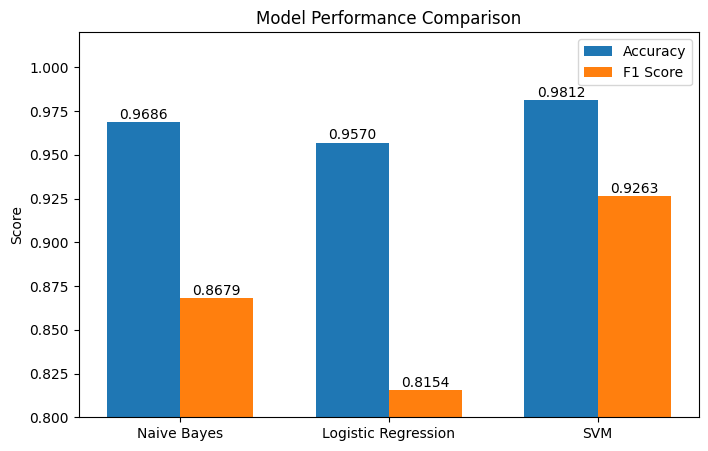

In [19]:
# Compare Model Performance using Graph

models = ['Naive Bayes', 'Logistic Regression', 'SVM']

accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, svm_pred)
]

f1_scores = [
    f1_score(y_test, nb_pred),
    f1_score(y_test, lr_pred),
    f1_score(y_test, svm_pred)
]

# Plot Graph
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

bars1 = plt.bar(x - width/2, accuracies, width, label='Accuracy')
bars2 = plt.bar(x + width/2, f1_scores, width, label='F1 Score')

# Add values on bars
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f'{height:.4f}',
        ha='center'
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f'{height:.4f}',
        ha='center'
    )

plt.xticks(x, models)
plt.ylabel("Score")

# Y-axis starts from 0.8
plt.ylim(0.8, 1.02)

plt.title("Model Performance Comparison")
plt.legend()

plt.show()

In [21]:
# Predict Custom SMS Messages using User Input

def predict_message(message):
    processed = preprocess_text(message)

    vector = tfidf.transform([processed]).toarray()

    prediction = svm_model.predict(vector)[0]

    if prediction == 1:
        return "Spam"
    else:
        return "Ham"


# Take input from user
user_message = input("Enter an SMS message: ")

# Predict result
result = predict_message(user_message)

print("\nPrediction:", result)

Enter an SMS message: Ok I'm gonna head up to usf in like fifteen minutes

Prediction: Ham
